In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

In [ ]:
air_passengers = pd.read_csv("AirPassengers.csv", header = 0, parse_dates = [0], names = ['Month', 'Passengers'], index_col = 0)

FileNotFoundError: [Errno 2] No such file or directory: 'AirPassengers.csv'

In [ ]:
log_air_passengers = np.log(air_passengers.Passengers)
log_air_passengers[1:10]

,Passengers
Month,
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
1949-06-01,4.905275
1949-07-01,4.997212
1949-08-01,4.997212
1949-09-01,4.912655
1949-10-01,4.779123


In [ ]:
log_air_passengers_diff = log_air_passengers - log_air_passengers.shift()

In [ ]:
log_air_passengers_diff.dropna(inplace=True)
log_air_passengers_diff[1:10]

,Passengers
Month,
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
1949-06-01,0.109484
1949-07-01,0.091937
1949-08-01,0.000000
1949-09-01,-0.084557
1949-10-01,-0.133531
1949-11-01,-0.134733


In [ ]:
# Let's talk about the ARIMA model
# Auto-Regressive Integrated Moving Average
# In this case we're talking about a series with dependence among values (more natural)

In [ ]:
# Nothing but a linear regression with a few times
# 1. The number of Auto-Regressive Terms (p)
# 2. The number of Moving Average Terms (q)
# 3. The number of differences taken

In [ ]:
# We don't pull these out of thin air, but rather draw them from the data
from statsmodels.tsa.stattools import acf, pacf
lag_acf = acf(log_air_passengers_diff.values, nlags = 20)
lag_pacf = pacf(log_air_passengers_diff.values, nlags = 20)

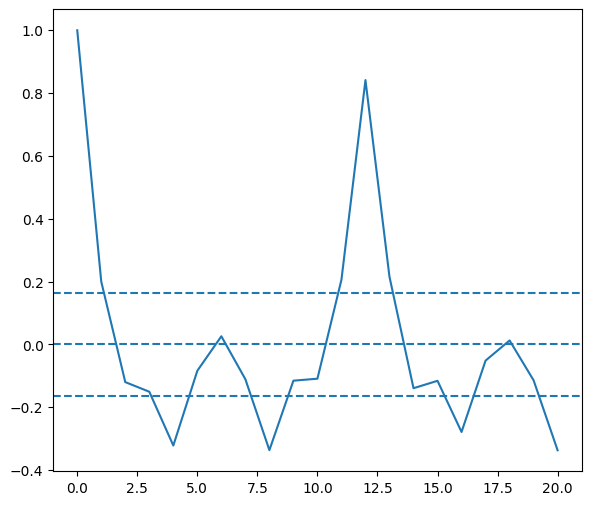

In [ ]:
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--')
plt.axhline(y=-1.96/np.sqrt(len(log_air_passengers_diff)),linestyle='--')
plt.axhline(y=1.96/np.sqrt(len(log_air_passengers_diff)),linestyle='--')

In [ ]:
# look at where the plot crosses the upper confidence interval for the first time
# for ACF this is 2 and gives us the p value

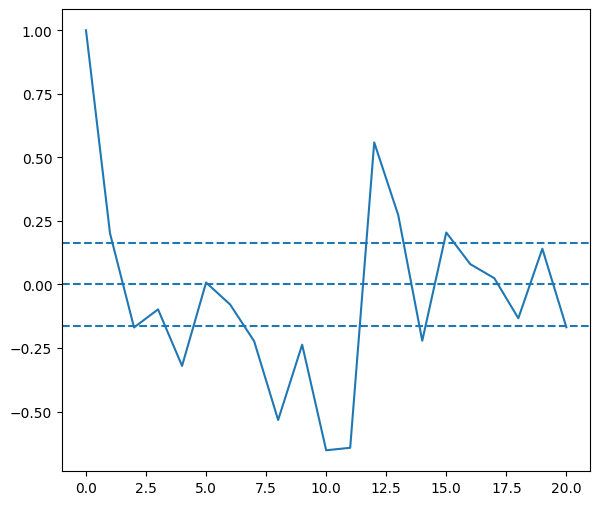

In [ ]:
plt.subplot(121)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--')
plt.axhline(y=-1.96/np.sqrt(len(log_air_passengers_diff)),linestyle='--')
plt.axhline(y=1.96/np.sqrt(len(log_air_passengers_diff)),linestyle='--')

In [ ]:
# look at where the plot crosses the upper confidence interval for the first time
# for PACF this is 2 and gives us the p value

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Text(0.5, 1.0, 'RSS: 23.7781')

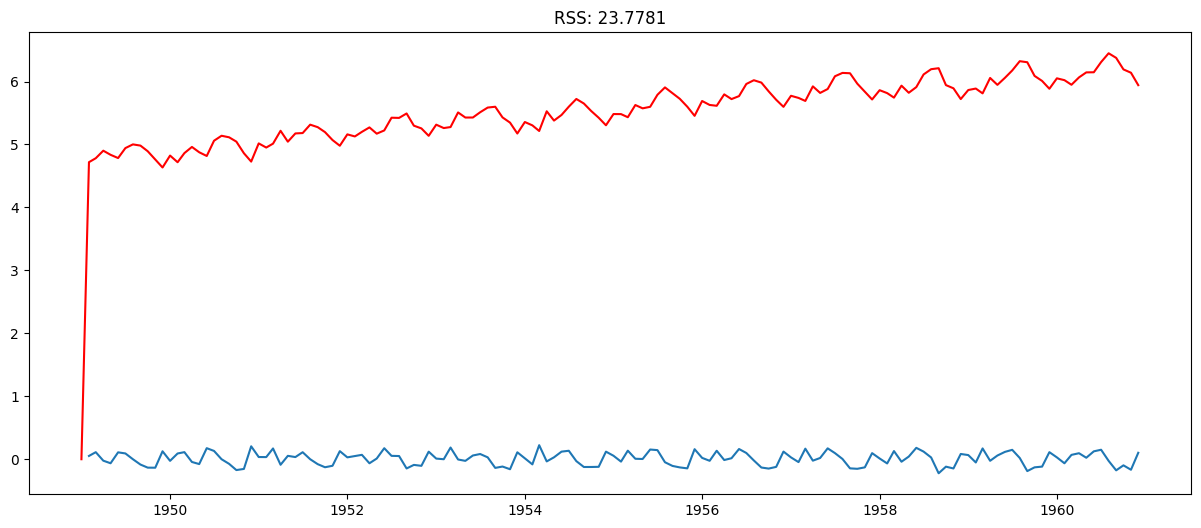

In [27]:
from statsmodels.tsa.arima.model import ARIMA
# AR model
model = ARIMA(log_air_passengers, order=(2, 1, 0))
results_AR = model.fit()
plt.plot(log_air_passengers_diff)
plt.plot(results_AR.fittedvalues, color='red') # This still plots fittedvalues against differenced, for comparison.
# Corrected RSS calculation for original log series:
plt.title('RSS: %.4f'% sum((results_AR.fittedvalues-log_air_passengers).dropna()**2))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Text(0.5, 1.0, 'RSS: 23.7528')

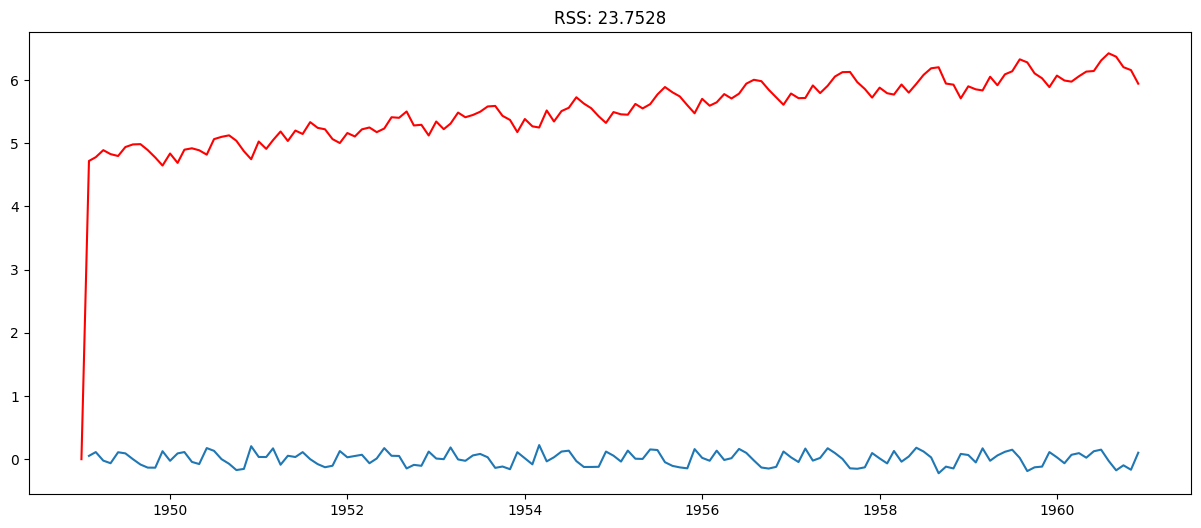

In [28]:
from statsmodels.tsa.arima.model import ARIMA
# MA model
model = ARIMA(log_air_passengers, order=(0, 1, 2))
results_MA = model.fit()
plt.plot(log_air_passengers_diff)
plt.plot(results_MA.fittedvalues, color='red') # This still plots fittedvalues against differenced, for comparison.
# Corrected RSS calculation for original log series:
plt.title('RSS: %.4f'% sum((results_MA.fittedvalues-log_air_passengers).dropna()**2))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Text(0.5, 1.0, 'RSS: 23.6421')

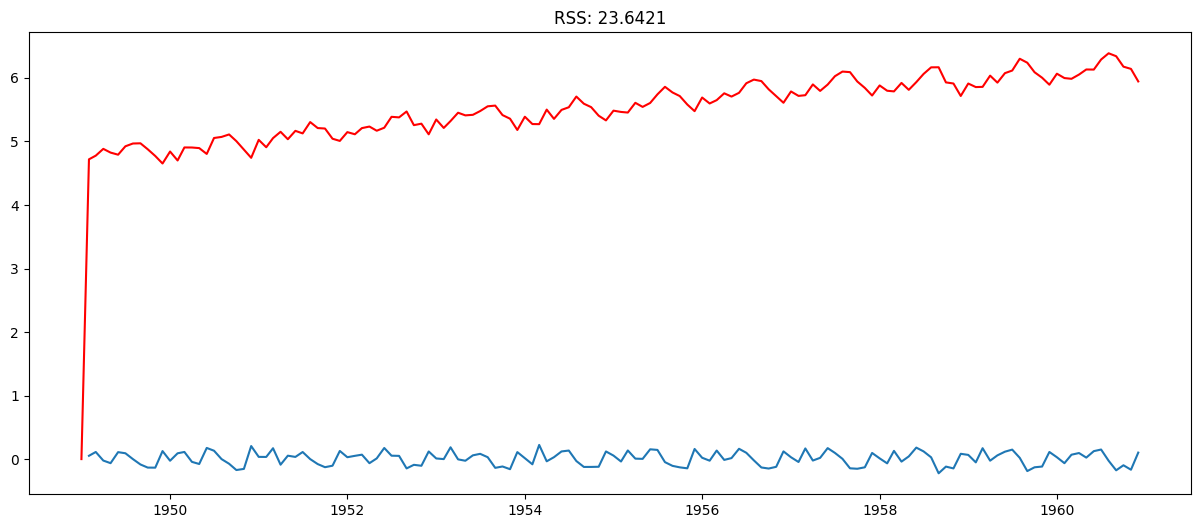

In [29]:
from statsmodels.tsa.arima.model import ARIMA
# ARIMA model
model = ARIMA(log_air_passengers, order=(2, 1, 2))
results_ARIMA = model.fit()
plt.plot(log_air_passengers_diff)
plt.plot(results_ARIMA.fittedvalues, color='red') # This still plots fittedvalues against differenced, for comparison.
# Corrected RSS calculation for original log series:
plt.title('RSS: %.4f'% sum((results_ARIMA.fittedvalues-log_air_passengers).dropna()**2))

In [30]:
# This cell is no longer needed as fittedvalues directly represent log predictions.
# predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
# print(predictions_ARIMA_diff.head())

In [31]:
# This cell is no longer needed as we directly use fittedvalues as log predictions.
# predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
# print(predictions_ARIMA_diff_cumsum.head())

In [32]:
# Direct assignment of log predictions from ARIMA fitted values, dropping initial NaNs
predictions_ARIMA_log = results_ARIMA.fittedvalues.dropna()
predictions_ARIMA_log.head()

,0
Month,
1949-01-01,0.000000
1949-02-01,4.718499
1949-03-01,4.776385
1949-04-01,4.883216
1949-05-01,4.824422


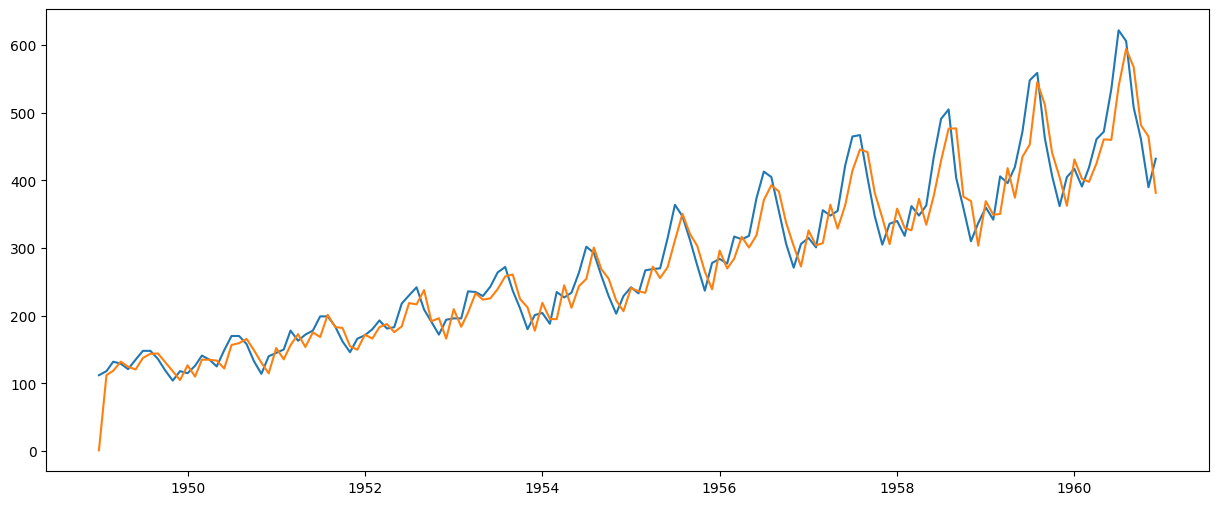

In [33]:
predictions_ARIMA = np.exp(predictions_ARIMA_log)
plt.plot(air_passengers)
plt.plot(predictions_ARIMA)